# Comparison: Old vs New Fitting Results

This notebook compares the curve-fitting results from two Differential Evolution runs on 145 experimental transmittance spectra.

- **old_data.npy**: Previous fitting parameters and MSEs
- **new_data.npy**: Latest fitting parameters and MSEs

We answer: **Is the fitting better with the old data or with the new data?**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_style('whitegrid')
plt.rcParams.update({'font.size': 12})

In [2]:
def modelo_transmitancia(x,
                         d,
                         rugo_1, rugo_2,
                         A, B, C, D, E,
                         alpha, beta, gamma,
                         ne):
    c = 3e8
    mu = 3.90e-4

    df = pd.read_csv('../../../experimental_samples/Background_data/TexpglassO.txt', sep="\t", header=0)
    t_v = df.values
    sellmeier = [A, B, C, D, E]
    absorcion = [alpha, beta, gamma]

    def frecuencia(x):
        return 2 * np.pi * c * 1e9 / x

    def gamma_f(x):
        return 2.8e11 * x

    def e1f_f(omega, gama, ne):
        return -(3182.61 * ne) / (omega**2 + gama**2)

    def e2f_f(omega, gama, ne):
        return (3182.61 * ne * gama) / (omega * (omega**2 + gama**2))

    def e1b_f(x, sellmeier):
        return sellmeier[0] + (sellmeier[1] * x**2)/(x**2 - sellmeier[2]**2 + 1e-6) + (sellmeier[3] * x**2)/(x**2 - sellmeier[4]**2 + 1e-6)

    def e2b_f(x):
        return 0.0

    def e1_f(e1f, e1b):
        return e1f + e1b

    def e2_f(e2f, e2b):
        return e2f + e2b

    def ng_f(t_v):
        return (1/t_v) + np.sqrt(1/(t_v**2) - 1)

    def n_f(e1, e2):
        return (1/np.sqrt(2)) * np.sqrt(e1 + np.sqrt(e1**2 + e2**2)) + 1e-6

    def kapa_f(e1, e2):
        return (1/np.sqrt(2)) * np.sqrt(-e1 + np.sqrt(e1**2 + e2**2))

    def neff1_f(n):
        return np.sqrt((1/2) * (n**2 + 1))

    def T1_f(neff1, x, n, rugo_1):
        return np.exp(-0.5 * (2 * np.pi * rugo_1 * (neff1 - 1))**2 / x**2) * (n/1) * (4/(n + 1)**2)

    def T2_f(neff1, x, ng, n, rugo_2):
        return np.exp(-0.5 * (1/x**2) * (2 * np.pi * rugo_2 * (neff1 - 1))**2) * (ng/n) * 4 * (n**2) * (1/(n + ng)**2)

    def T3_f(ng):
        return (1/ng) * 4 * ng**2 * (1/(1 + ng)**2)

    def R1_f(n, x, rugo_1):
        return np.exp(-2 * (2 * np.pi * rugo_1 * n)**2 * (1/x)**2) * (n - 1)**2 * (1/(n + 1))**2

    def R2_f(n, x, ng, rugo_2):
        return np.exp(-2 * (2 * np.pi * rugo_2 * n)**2 * (1/x)**2) * (n - ng)**2 * (1/(n + ng))**2

    def R21_f(n, ng):
        return (n - ng)**2 * (1/(n + ng)**2)

    def R3_f(ng):
        return (ng - 1)**2 * (1/(ng + 1)**2)

    def phi_f(n, d, x):
        return 4 * np.pi * n * d * (1/x)

    def alfa_f(kapa, x, absorcion):
        return kapa * 4 * np.pi * (1/x) + absorcion[0] * np.exp(1240 * absorcion[1] * ((1/x) - (1/absorcion[2])))

    def Tf_f(T1, T2, alfa, d, phi, R1, R2):
        exp1 = np.exp(np.clip(-alfa * d, -700, 700))
        exp2 = np.exp(np.clip(-2 * alfa * d, -700, 700))
        denominator = 1 - 2 * np.sqrt(R1 * R2) * np.cos(phi) * exp1 + R1 * R2 * exp2
        return (T1 * T2) * exp1 / denominator

    def T_f(T3, R21, R3, Tf):
        return 1.0 * ((T3 / (1 - R21 * R3)) * Tf * 100)

    omega = frecuencia(x)
    gama = gamma_f(x)
    e1f = e1f_f(omega, gama, ne)
    e2f = e2f_f(omega, gama, ne)
    e1b = e1b_f(x, sellmeier)
    e2b = e2b_f(x)
    e1 = e1_f(e1f, e1b)
    e2 = e2_f(e2f, e2b)
    ng = ng_f(t_v[:, 1])
    n = n_f(e1, e2)
    kapa = kapa_f(e1, e2)
    neff1 = neff1_f(n)
    T1 = T1_f(neff1, x, n, rugo_1)
    T2 = T2_f(neff1, x, ng, n, rugo_2)
    T3 = T3_f(ng)
    R1 = R1_f(n, x, rugo_1)
    R2 = R2_f(n, x, ng, rugo_2)
    R21 = R21_f(n, ng)
    R3 = R3_f(ng)
    phi = phi_f(n, d, x)
    alfa = alfa_f(kapa, x, absorcion)
    Tf = Tf_f(T1, T2, alfa, d, phi, R1, R2)
    T = T_f(T3, R21, R3, Tf)

    if np.isnan(T).any():
        print('NAN: T')

    return np.nan_to_num(T, nan=1e-6)

In [3]:
old_data = np.load('old_data.npy')
new_data = np.load('new_data.npy')

exp_df = pd.read_pickle('../../../results/dataframe_spectrum_thickness_145_final.pkl')

x_wavelength = np.arange(190, 1101, 1)
param_names = ['d', 'rugo_1', 'rugo_2', 'A', 'B', 'C', 'D', 'E', 'alpha', 'beta', 'gamma', 'ne']

print(f'Old data shape: {old_data.shape}')
print(f'New data shape: {new_data.shape}')
print(f'Experimental data shape: {exp_df.shape}')
print(f'Wavelength range: {x_wavelength[0]} - {x_wavelength[-1]} nm ({len(x_wavelength)} points)')
print()
print('Columns: [idx, d, rugo_1, rugo_2, A, B, C, D, E, alpha, beta, gamma, ne, MSE]')

Old data shape: (145, 14)
New data shape: (145, 14)
Experimental data shape: (145, 6)
Wavelength range: 190 - 1100 nm (911 points)

Columns: [idx, d, rugo_1, rugo_2, A, B, C, D, E, alpha, beta, gamma, ne, MSE]


## 1. MSE Statistical Comparison

The Mean Squared Error (MSE) is used as the objective function for the Differential Evolution optimization. The fitting was performed on the wavelength range **400-1100 nm** (indices 210+ of the wavelength array).

In [4]:
old_mse = old_data[:, -1]
new_mse = new_data[:, -1]

old_mse_sorted = old_mse[np.argsort(old_data[:, 0])] # This element organize them 
new_mse_sorted = new_mse[np.argsort(new_data[:, 0])]

new_wins = np.sum(new_mse_sorted < old_mse_sorted) # Comparsion between both algorithms 
old_wins = np.sum(old_mse_sorted < new_mse_sorted)
ties = np.sum(np.isclose(new_mse_sorted, old_mse_sorted, rtol=1e-12)) 

print('=' * 60)
print('MSE COMPARISON: Old vs New (145 spectra)')
print('=' * 60)
print()
print(f'{"Statistic":<20} {"Old":>15} {"New":>15} {"Delta":>15}')
print('-' * 65)
print(f'{"Mean MSE":<20} {np.mean(old_mse):>15.6f} {np.mean(new_mse):>15.6f} {np.mean(new_mse - old_mse):>+15.6f}')
print(f'{"Median MSE":<20} {np.median(old_mse):>15.6f} {np.median(new_mse):>15.6f} {np.median(new_mse - old_mse):>+15.6f}')
print(f'{"Std MSE":<20} {np.std(old_mse):>15.6f} {np.std(new_mse):>15.6f} {"---":>15}')
print(f'{"Min MSE":<20} {np.min(old_mse):>15.6f} {np.min(new_mse):>15.6f} {np.min(new_mse - old_mse):>+15.6f}')
print(f'{"Max MSE":<20} {np.max(old_mse):>15.6f} {np.max(new_mse):>15.6f} {np.max(new_mse - old_mse):>+15.6f}')
print()
print(f'New better (lower MSE): {new_wins} / 145 ({100*new_wins/145:.1f}%)')
print(f'Old better (lower MSE): {old_wins} / 145 ({100*old_wins/145:.1f}%)')
print(f'Ties:                    {ties} / 145')
print()
mask_new = new_mse_sorted < old_mse_sorted
mask_old = new_mse_sorted > old_mse_sorted
avg_impr = np.mean(new_mse_sorted[mask_new] - old_mse_sorted[mask_new])
avg_regr = np.mean(new_mse_sorted[mask_old] - old_mse_sorted[mask_old])
print(f'Avg improvement when new is better: {avg_impr:.6f}')
print(f'Avg regression when old is better:  {avg_regr:.6f}')

MSE COMPARISON: Old vs New (145 spectra)

Statistic                        Old             New           Delta
-----------------------------------------------------------------
Mean MSE                    1.098788        1.185685       +0.086897
Median MSE                  0.757244        0.742678       -0.023595
Std MSE                     0.954382        1.188938             ---
Min MSE                     0.061126        0.072714       -3.089667
Max MSE                     4.674535        5.931636       +5.574584

New better (lower MSE): 49 / 145 (33.8%)
Old better (lower MSE): 96 / 145 (66.2%)
Ties:                    0 / 145

Avg improvement when new is better: -0.256005
Avg regression when old is better:  0.261920


/tmp/ipykernel_6757/3815469531.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([old_mse, new_mse], labels=['Old', 'New'], patch_artist=True, widths=0.5)


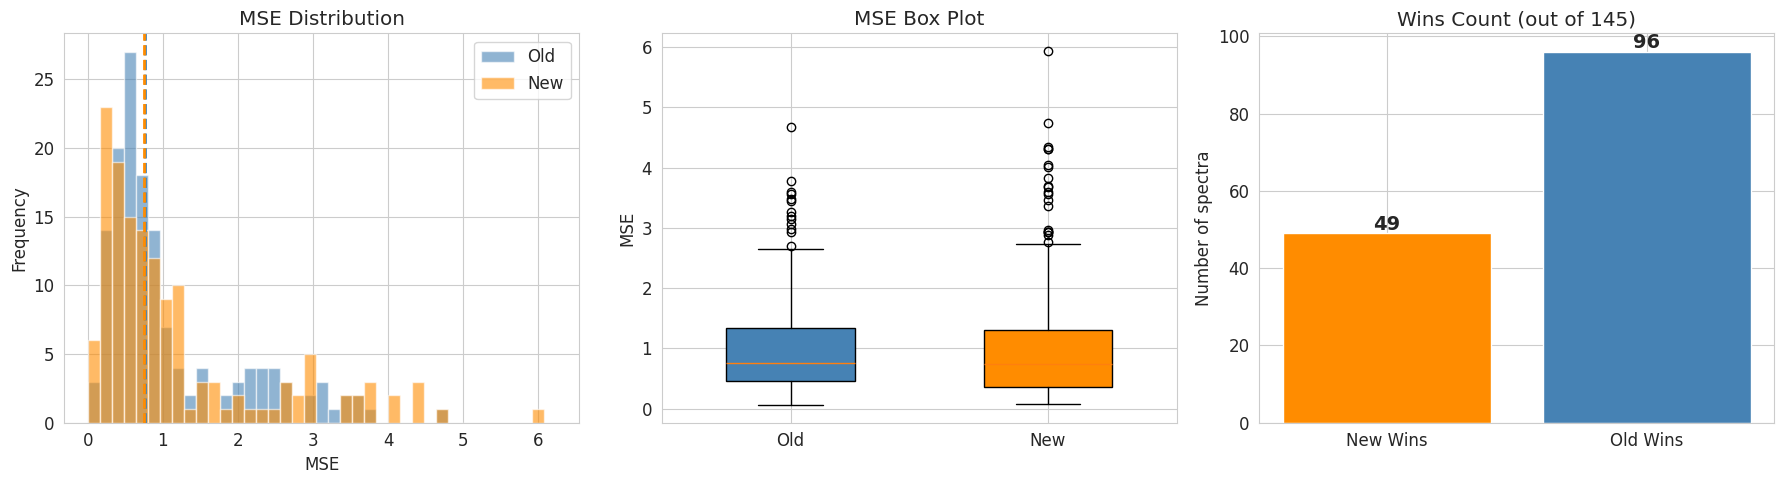

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
bins = np.linspace(0, max(np.max(old_mse), np.max(new_mse)) * 1.05, 40)
ax.hist(old_mse, bins=bins, alpha=0.6, label='Old', color='steelblue', edgecolor='white')
ax.hist(new_mse, bins=bins, alpha=0.6, label='New', color='darkorange', edgecolor='white')
ax.axvline(np.median(old_mse), color='steelblue', linestyle='--', linewidth=2)
ax.axvline(np.median(new_mse), color='darkorange', linestyle='--', linewidth=2)
ax.set_xlabel('MSE')
ax.set_ylabel('Frequency')
ax.set_title('MSE Distribution')
ax.legend()

ax = axes[1]
bp = ax.boxplot([old_mse, new_mse], labels=['Old', 'New'], patch_artist=True, widths=0.5)
bp['boxes'][0].set_facecolor('steelblue')
bp['boxes'][1].set_facecolor('darkorange')
ax.set_ylabel('MSE')
ax.set_title('MSE Box Plot')

ax = axes[2]
ax.bar(['New Wins', 'Old Wins'], [new_wins, old_wins], color=['darkorange', 'steelblue'], edgecolor='white')
ax.set_ylabel('Number of spectra')
ax.set_title(f'Wins Count (out of 145)')
for i, v in enumerate([new_wins, old_wins]):
    ax.text(i, v + 1, str(v), ha='center', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('./images/mse_comparison_summary.png', dpi=150, bbox_inches='tight')
plt.show()

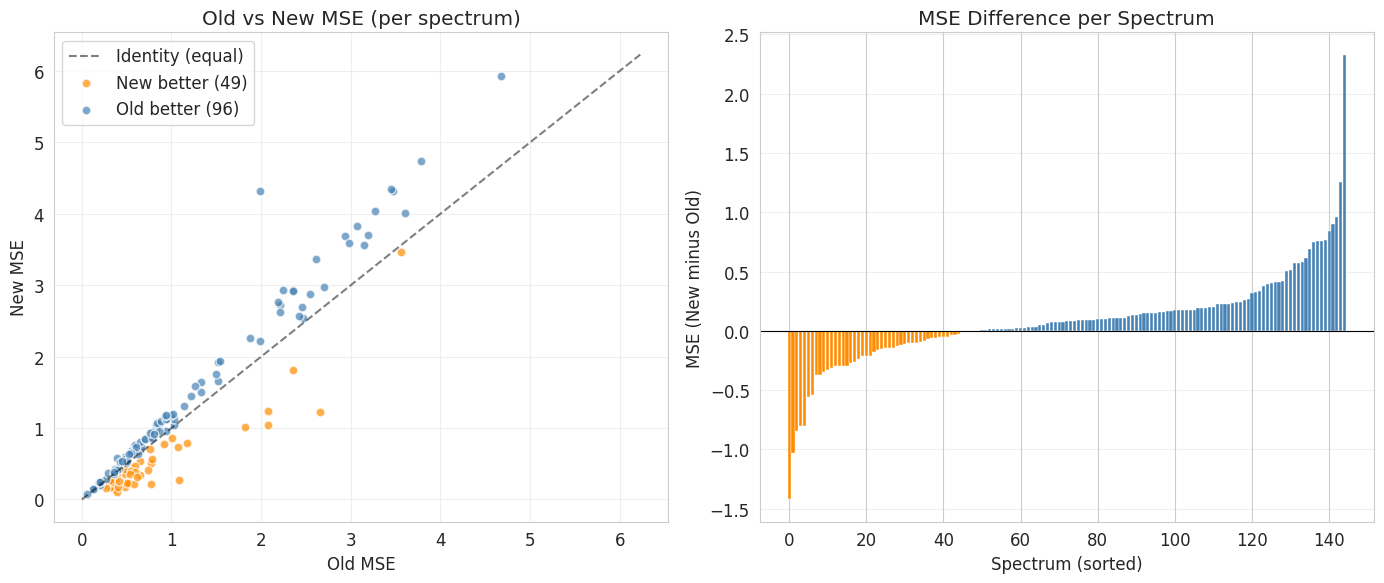

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
max_mse = max(np.max(old_mse_sorted), np.max(new_mse_sorted)) * 1.05
ax.plot([0, max_mse], [0, max_mse], 'k--', alpha=0.5, label='Identity (equal)')

better_new = new_mse_sorted < old_mse_sorted
better_old = new_mse_sorted > old_mse_sorted

ax.scatter(old_mse_sorted[better_new], new_mse_sorted[better_new],
           c='darkorange', alpha=0.7, s=40, label=f'New better ({new_wins})', edgecolors='white')
ax.scatter(old_mse_sorted[better_old], new_mse_sorted[better_old],
           c='steelblue', alpha=0.7, s=40, label=f'Old better ({old_wins})', edgecolors='white')

ax.set_xlabel('Old MSE')
ax.set_ylabel('New MSE')
ax.set_title('Old vs New MSE (per spectrum)')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
mse_diff = new_mse_sorted - old_mse_sorted
sorted_idx = np.argsort(mse_diff)
colors = ['darkorange' if v < 0 else 'steelblue' for v in mse_diff[sorted_idx]]
ax.bar(range(145), mse_diff[sorted_idx], color=colors, edgecolor='white', linewidth=0.3)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlabel('Spectrum (sorted)')
ax.set_ylabel('MSE (New minus Old)')
ax.set_title('MSE Difference per Spectrum')
ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('./images/mse_scatter_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Per-Sample Analysis

Identify which spectra improved the most and which regressed the most.

In [7]:
mse_diff_full = new_mse_sorted - old_mse_sorted
sorted_by_diff = np.argsort(mse_diff_full)

print('=' * 80)
print('TOP 10 MOST IMPROVED (New < Old)')
print('=' * 80)
print(f'{"#":>4} {"Sample":>12} {"Thick":>10} {"Old MSE":>12} {"New MSE":>12} {"Delta":>12} {"% Change":>10}')
print('-' * 80)
for rank, idx in enumerate(sorted_by_diff[:10]):
    orig_idx = int(old_data[idx, 0])
    sname = exp_df['Nombre'].iloc[orig_idx]
    thick = exp_df['Espesor'].iloc[orig_idx]
    print(f'{rank+1:>4} {sname:>12} {thick:>10.1f} {old_mse_sorted[idx]:>12.4f} {new_mse_sorted[idx]:>12.4f} {mse_diff_full[idx]:>+12.4f} {100*mse_diff_full[idx]/old_mse_sorted[idx]:>+9.1f}%')

print()
print('=' * 80)
print('TOP 10 MOST REGRESSED (New > Old)')
print('=' * 80)
print(f'{"#":>4} {"Sample":>12} {"Thick":>10} {"Old MSE":>12} {"New MSE":>12} {"Delta":>12} {"% Change":>10}')
print('-' * 80)
for rank, idx in enumerate(sorted_by_diff[-10:][::-1]):
    orig_idx = int(old_data[idx, 0])
    sname = exp_df['Nombre'].iloc[orig_idx]
    thick = exp_df['Espesor'].iloc[orig_idx]
    print(f'{rank+1:>4} {sname:>12} {thick:>10.1f} {old_mse_sorted[idx]:>12.4f} {new_mse_sorted[idx]:>12.4f} {mse_diff_full[idx]:>+12.4f} {100*mse_diff_full[idx]/old_mse_sorted[idx]:>+9.1f}%')

TOP 10 MOST IMPROVED (New < Old)
   #       Sample      Thick      Old MSE      New MSE        Delta   % Change
--------------------------------------------------------------------------------
   1       ANZO32       91.2       2.6531       1.2315      -1.4216     -53.6%
   2     ANZO02-3     1121.5       2.0738       1.0477      -1.0260     -49.5%
   3     ANZO494M      709.6       2.0764       1.2342      -0.8422     -40.6%
   4     ANZO664M      517.0       1.8175       1.0118      -0.8057     -44.3%
   5       ANZO48      440.6       1.0782       0.2731      -0.8052     -74.7%
   6     ANZO25-1     1217.0       0.7671       0.2137      -0.5533     -72.1%
   7     ANZO44-1      498.6       2.3599       1.8187      -0.5411     -22.9%
   8     AZO3Min3      228.9       1.1692       0.7949      -0.3743     -32.0%
   9     ANZO48-2      437.5       0.5846       0.2120      -0.3726     -63.7%
  10     ANZO44-2      457.2       1.0737       0.7307      -0.3430     -31.9%

TOP 10 MOST REGR

## 3. Visual Spectrum Comparison

Plot all 145 spectra with experimental data and both model predictions.

- **Black dots**: Experimental  |  **Blue**: Old params  |  **Orange**: New params
- **Green title**: New is better  |  **Red title**: Old is better
- Dashed line at 400 nm marks the start of the fitting region.

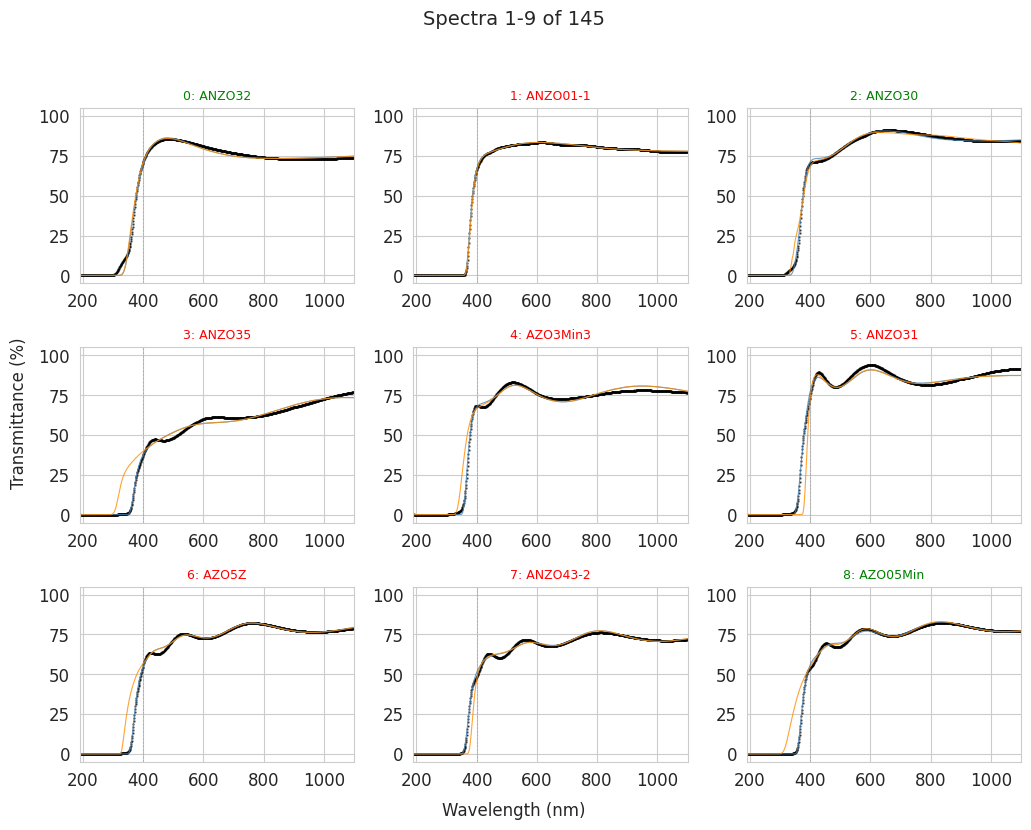

Batch 1/17 saved.


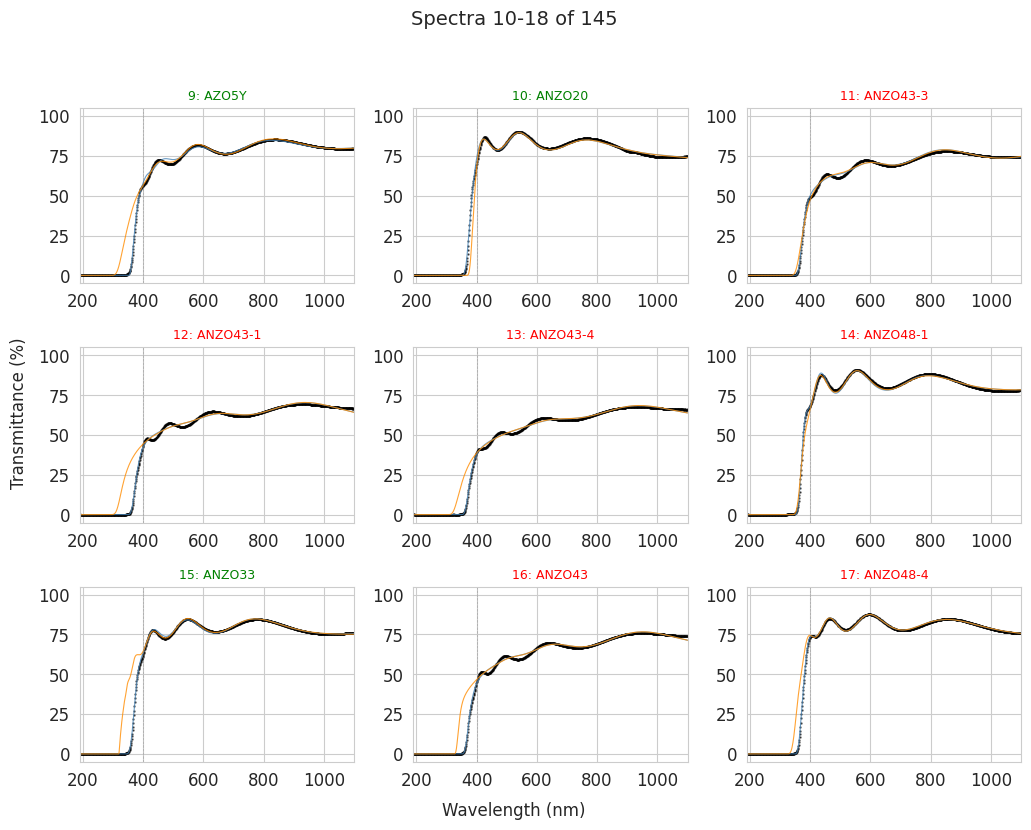

Batch 2/17 saved.


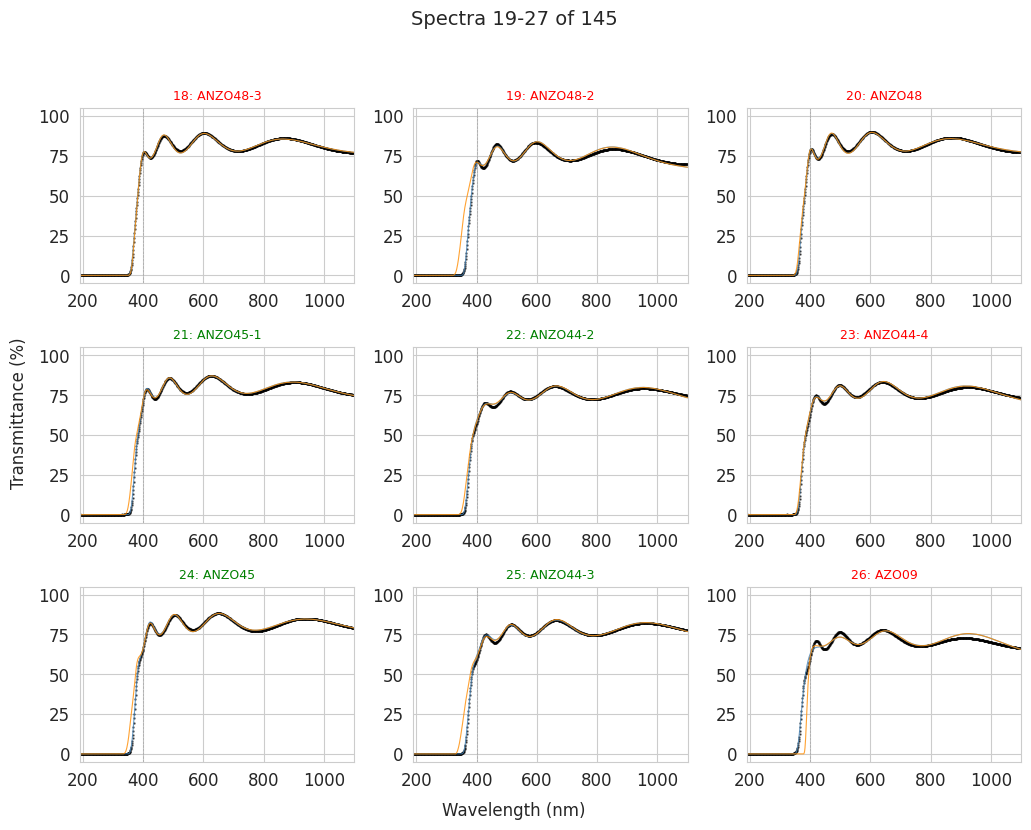

Batch 3/17 saved.


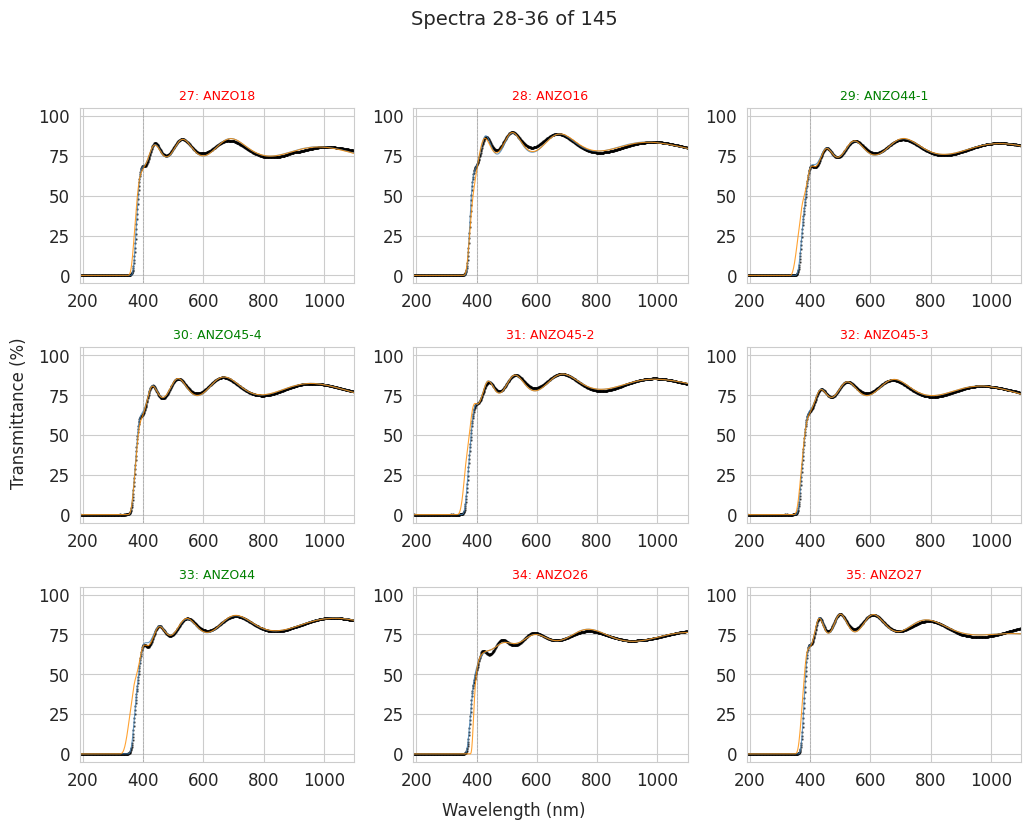

Batch 4/17 saved.


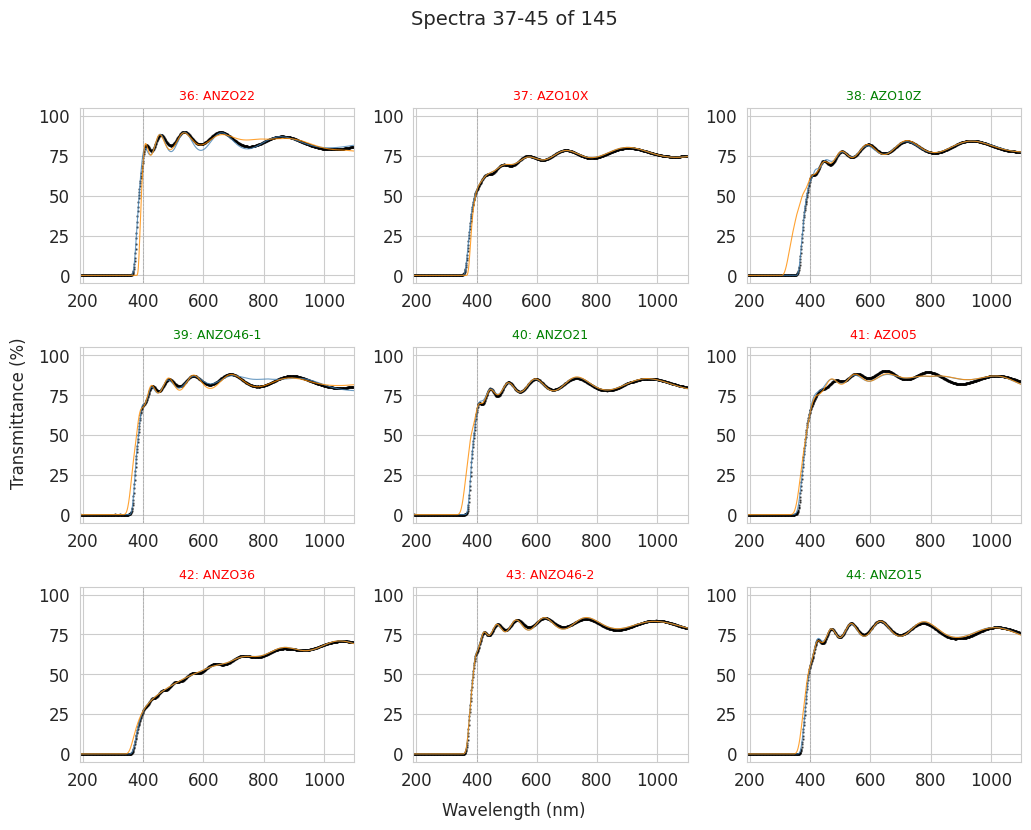

Batch 5/17 saved.


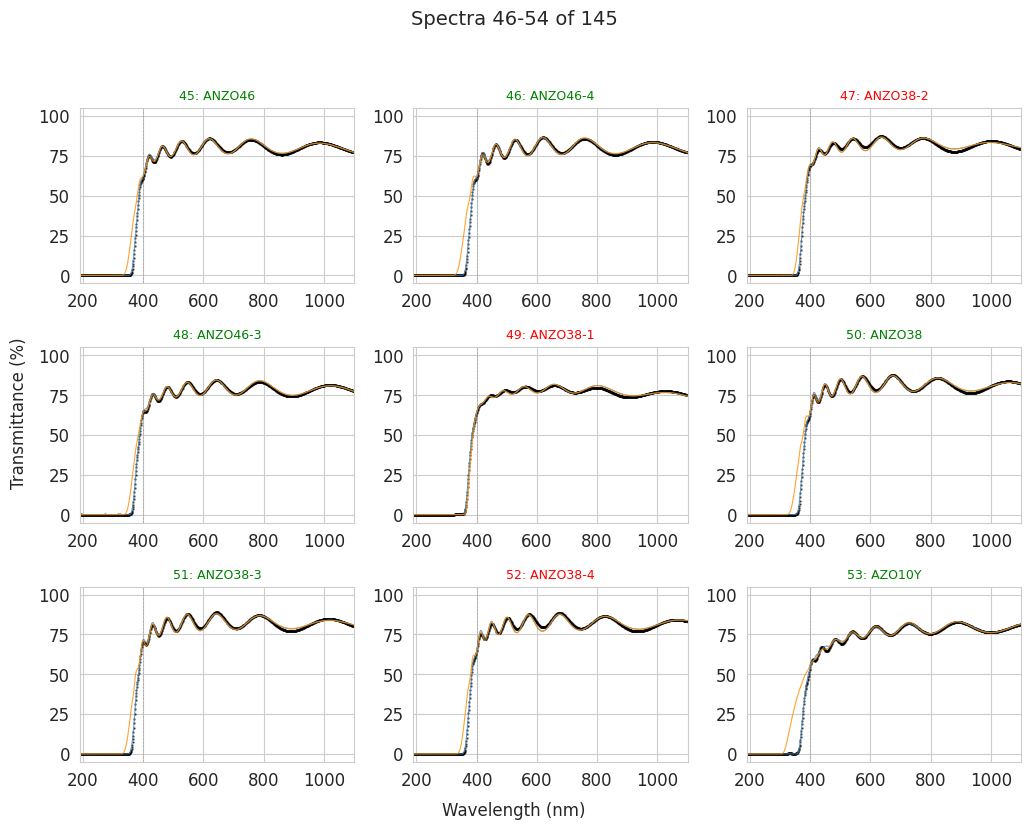

Batch 6/17 saved.


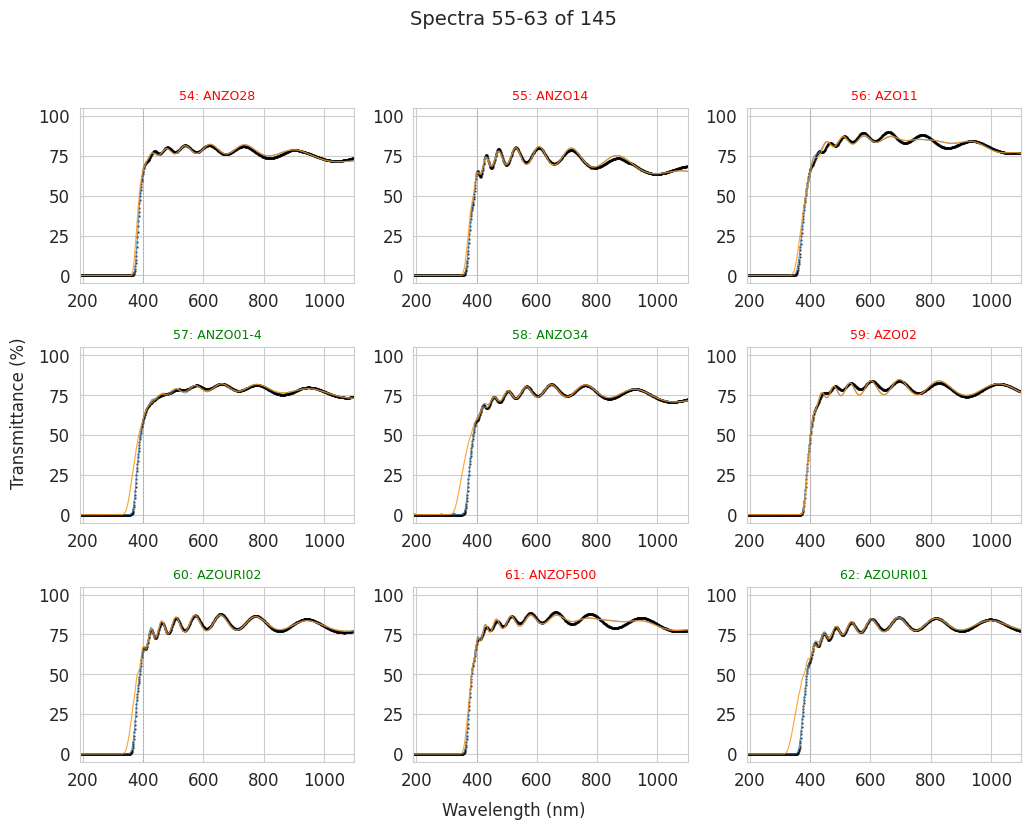

Batch 7/17 saved.


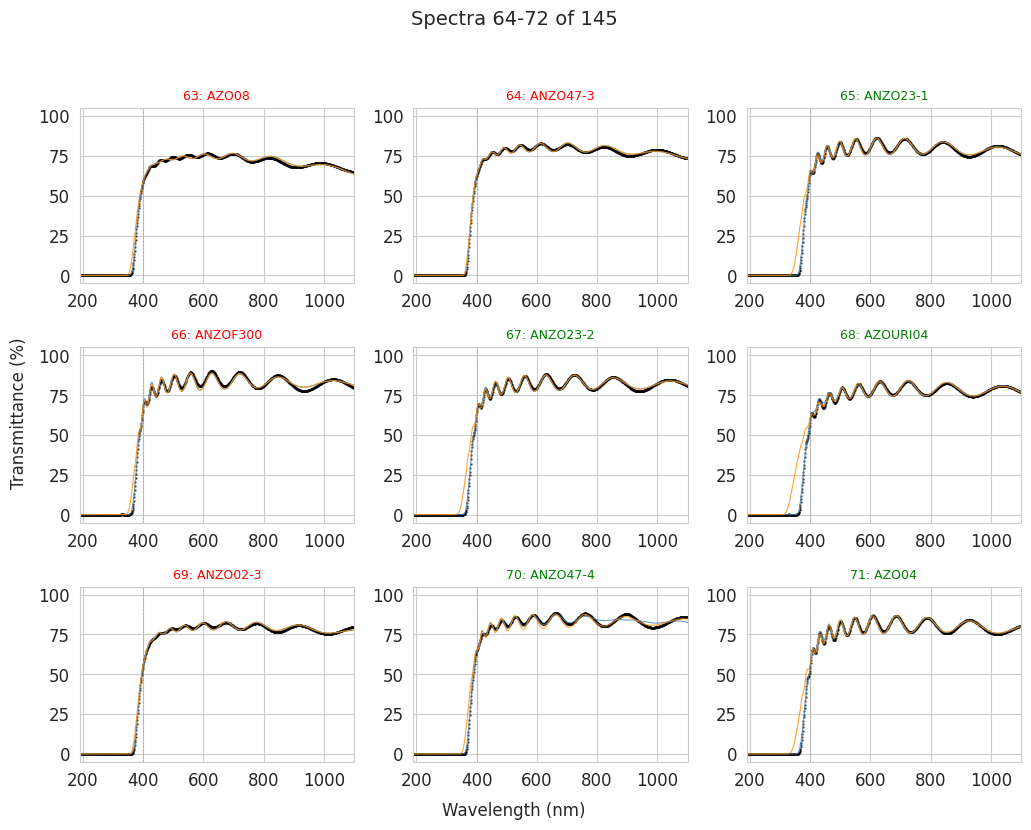

Batch 8/17 saved.


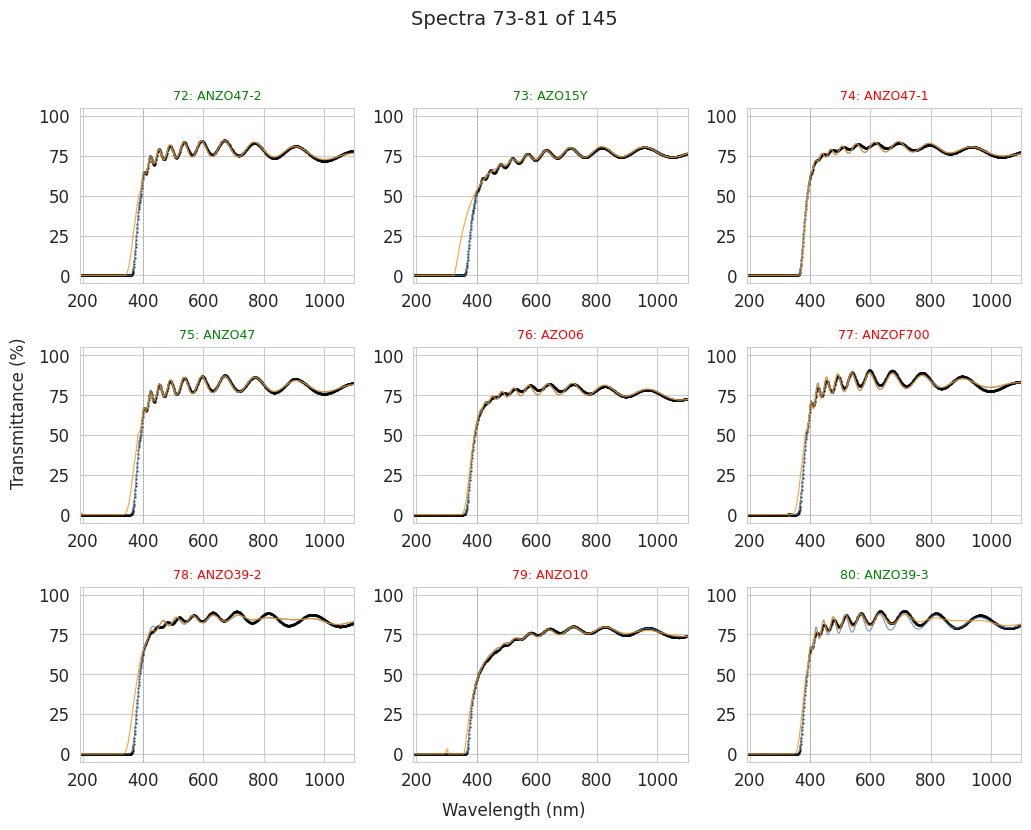

Batch 9/17 saved.


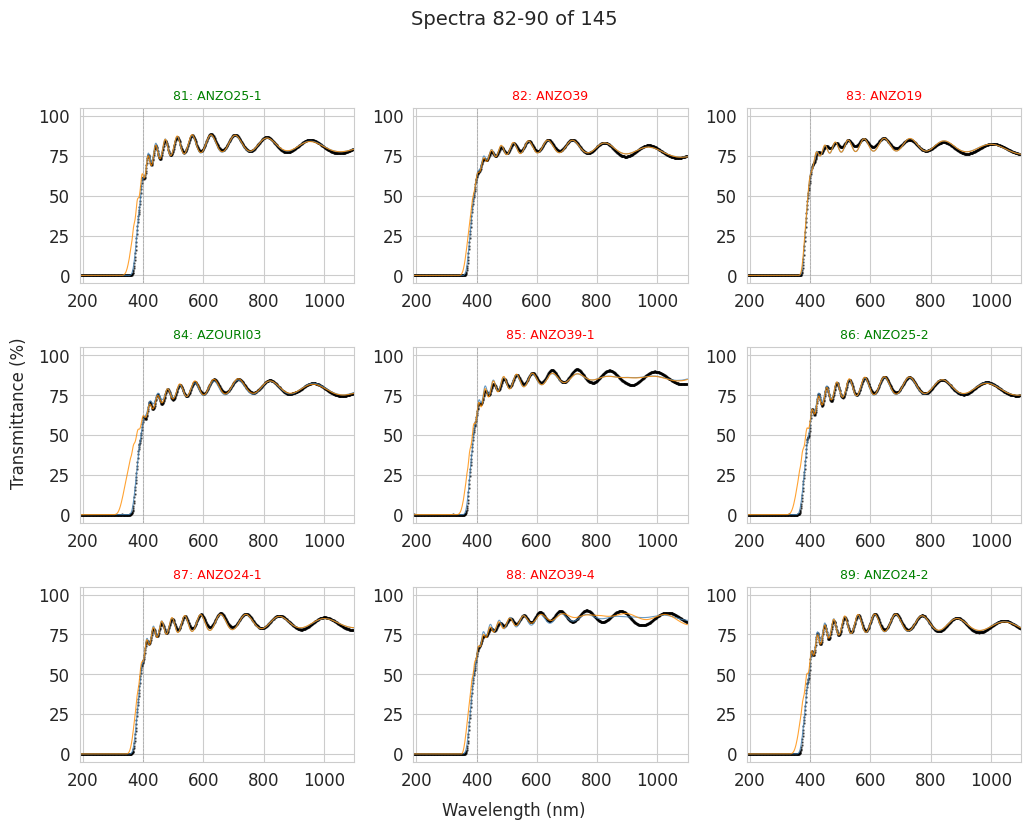

Batch 10/17 saved.


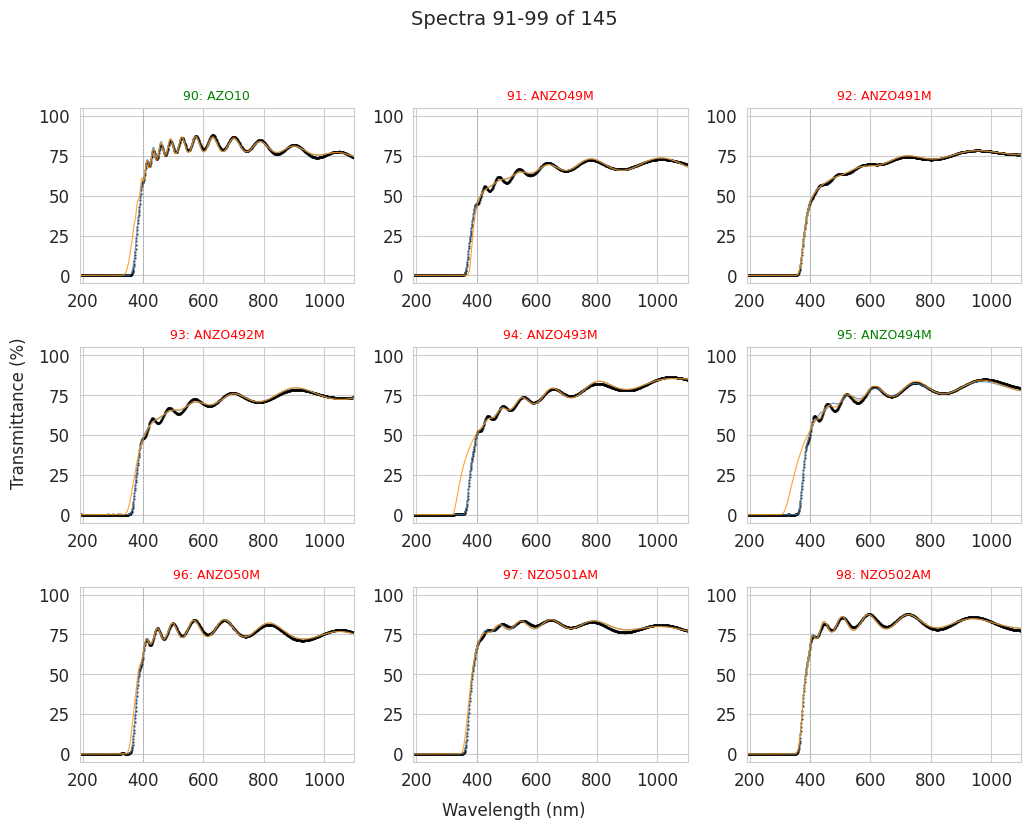

Batch 11/17 saved.


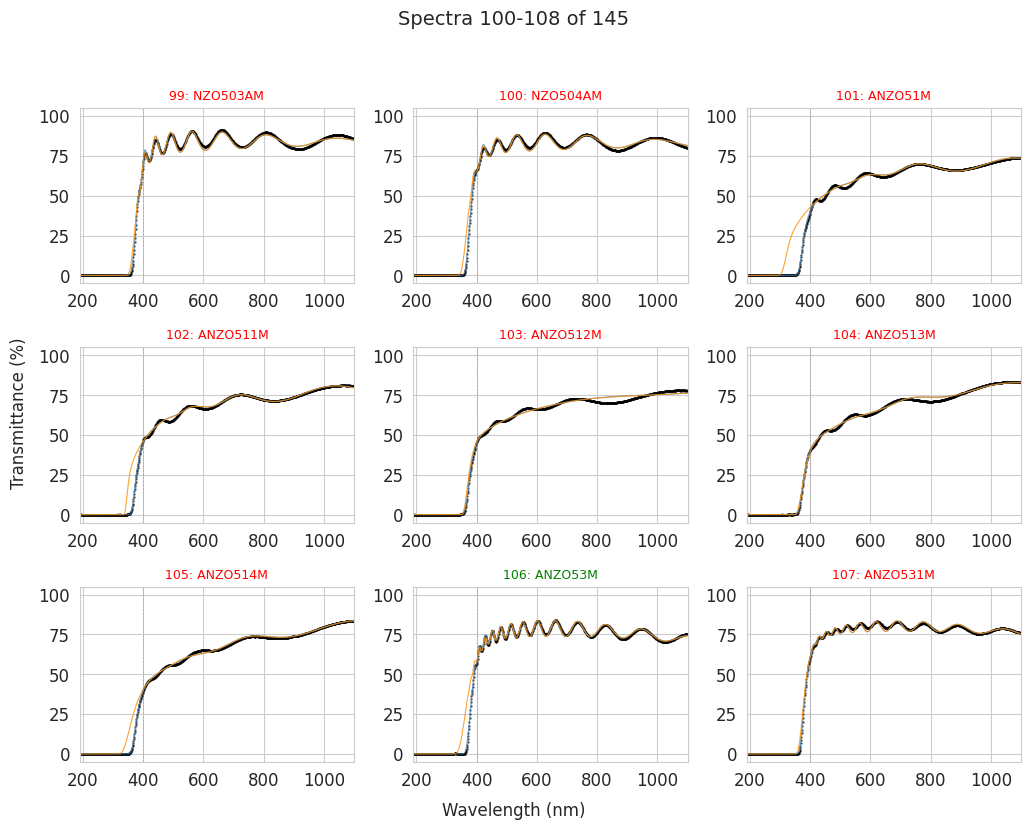

Batch 12/17 saved.


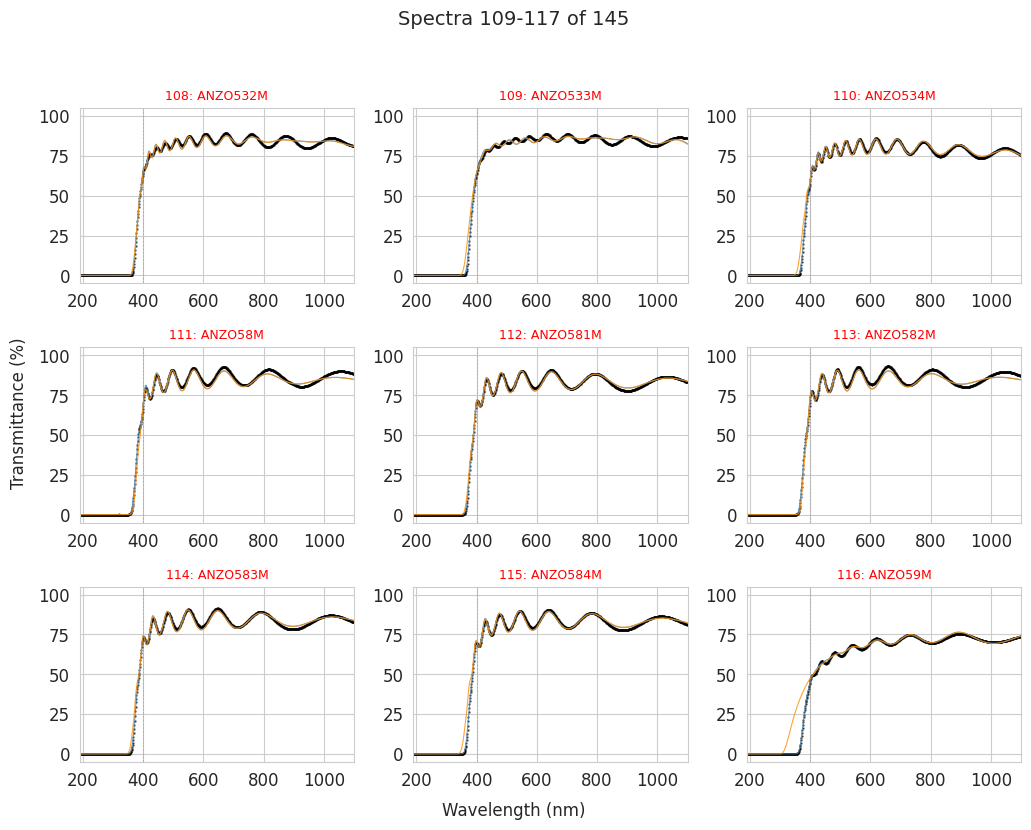

Batch 13/17 saved.


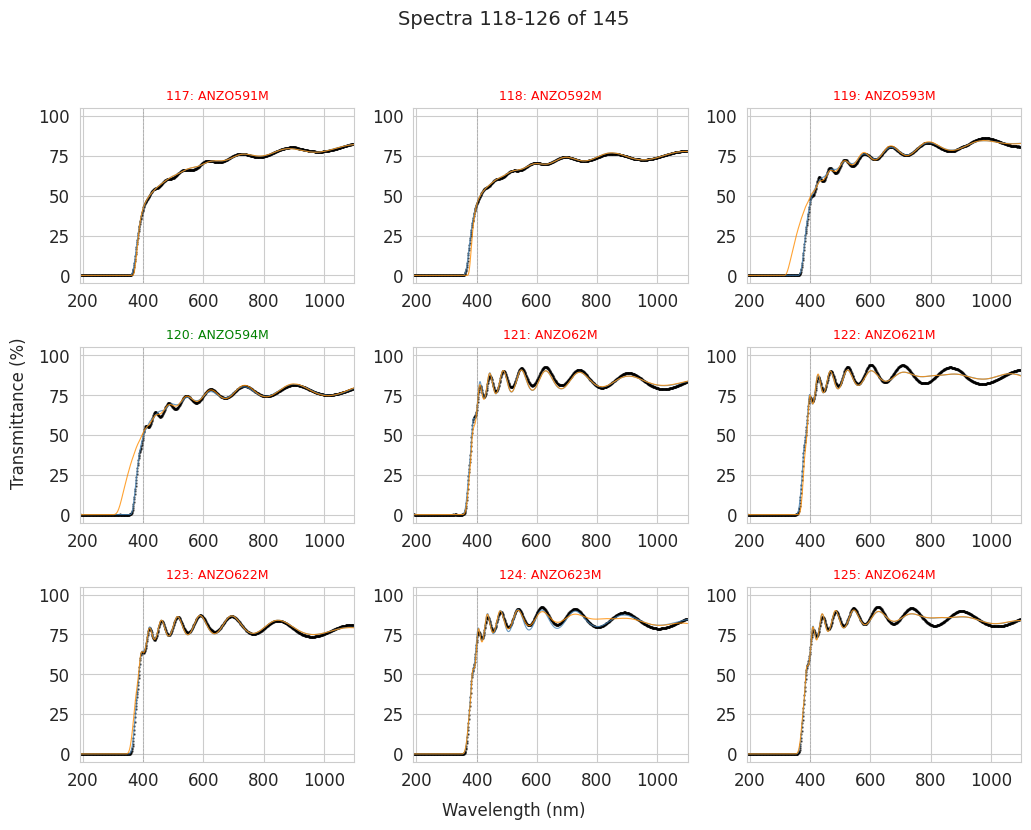

Batch 14/17 saved.


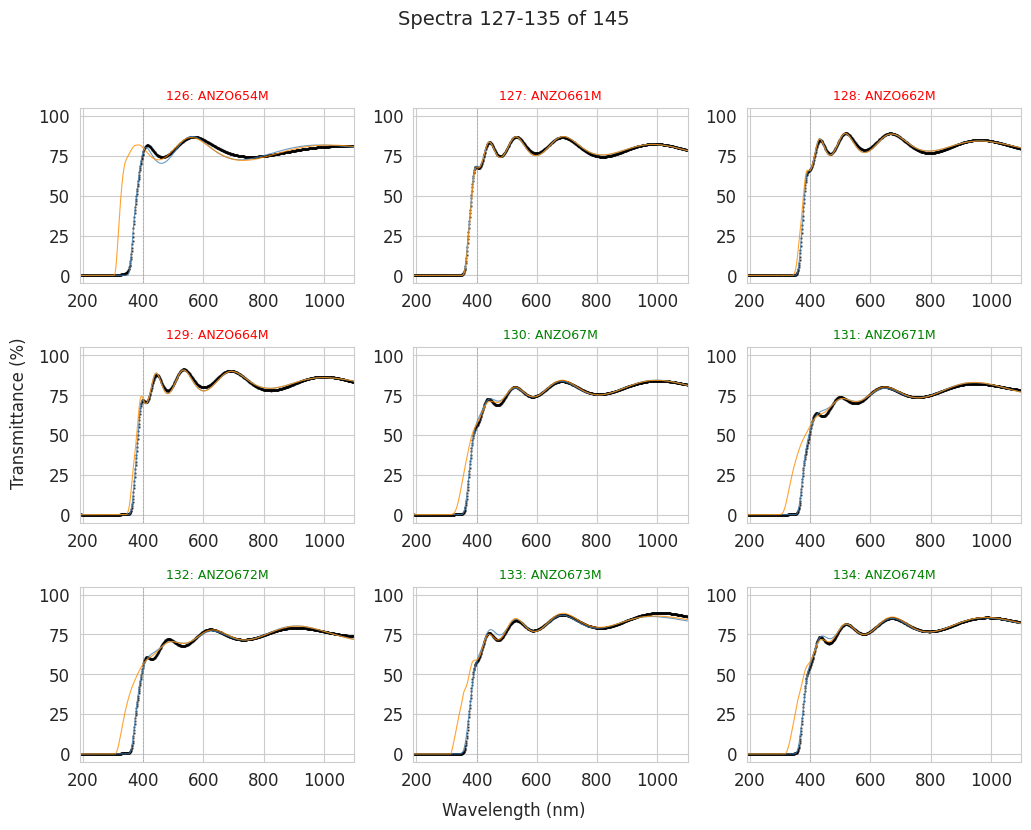

Batch 15/17 saved.


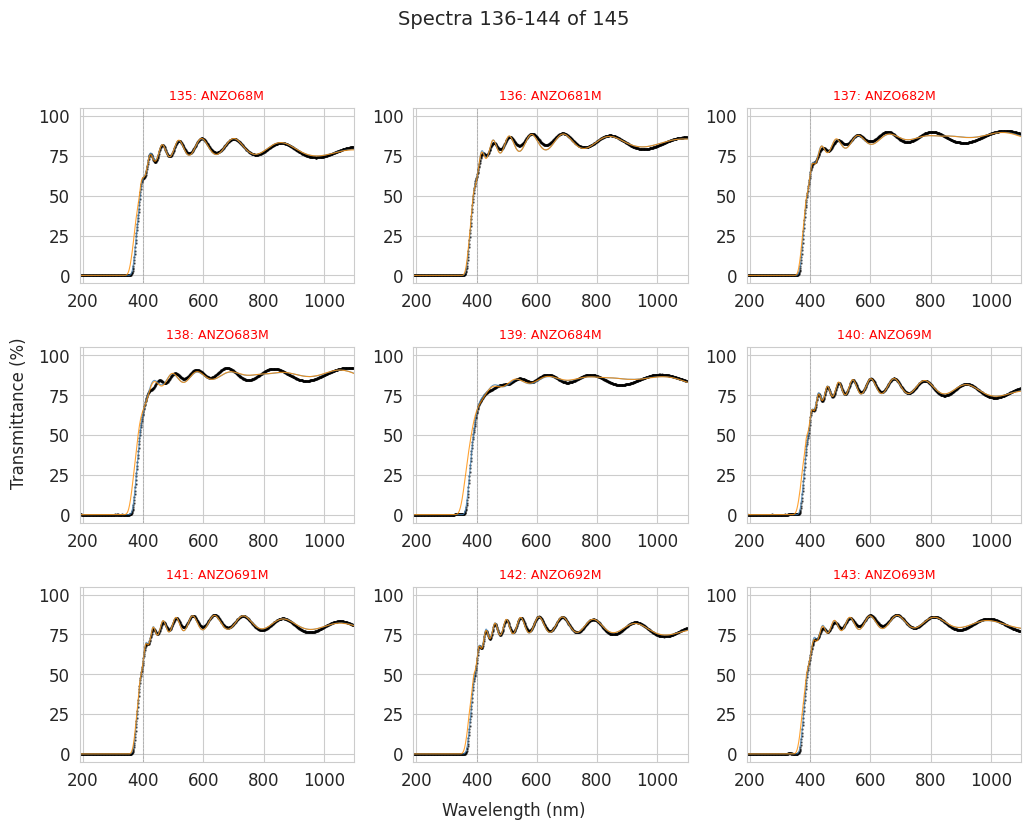

Batch 16/17 saved.


AttributeError: 'numpy.ndarray' object has no attribute 'plot'

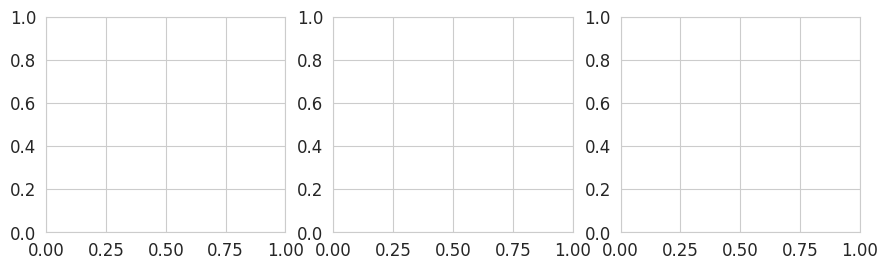

In [8]:
BATCH_SIZE = 9 # 30
num_batches = int(np.ceil(145 / BATCH_SIZE))

for batch in range(num_batches):
    start = batch * BATCH_SIZE
    end = min((batch + 1) * BATCH_SIZE, 145)
    n_plots = end - start

    cols = 3
    rows = int(np.ceil(n_plots / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3.5, rows * 2.8))
    axes = axes.flatten() if n_plots > 1 else [axes]

    for i in range(n_plots):
        ax = axes[i]
        spec_idx = start + i
        sample_name = exp_df['Nombre'].iloc[spec_idx]

        y_exp = exp_df['Espectro'].iloc[spec_idx][0].squeeze()
        old_params = old_data[np.argsort(old_data[:, 0])][spec_idx, 1:-1]
        new_params = new_data[np.argsort(new_data[:, 0])][spec_idx, 1:-1]

        y_old = modelo_transmitancia(x_wavelength, *old_params)
        y_new = modelo_transmitancia(x_wavelength, *new_params)

        old_mse_val = old_mse_sorted[spec_idx]
        new_mse_val = new_mse_sorted[spec_idx]

        ax.plot(x_wavelength, y_exp, 'k.', markersize=1.5, alpha=0.6, label='Exp')
        ax.plot(x_wavelength, y_old, '-', color='steelblue', linewidth=0.8, alpha=0.8, label=f'Old ({old_mse_val:.2f})')
        ax.plot(x_wavelength, y_new, '-', color='darkorange', linewidth=0.8, alpha=0.8, label=f'New ({new_mse_val:.2f})')
        ax.axvline(400, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)

        title_color = 'green' if new_mse_val < old_mse_val else 'red'
        ax.set_title(f'{spec_idx}: {sample_name}', fontsize=9, color=title_color)
        ax.set_xlim(190, 1100)
        ax.set_ylim(-5, 105)

    for j in range(n_plots, len(axes)):
        axes[j].set_visible(False)

    fig.text(0.5, 0.02, 'Wavelength (nm)', ha='center', fontsize=12)
    fig.text(0.02, 0.5, 'Transmittance (%)', va='center', rotation='vertical', fontsize=12)
    fig.suptitle(f'Spectra {start+1}-{end} of 145', fontsize=14, y=0.98)

    plt.tight_layout(rect=[0.03, 0.03, 1, 0.95])
    plt.savefig(f'./images/batches/spectra_batch_{batch+1:02d}.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(f'Batch {batch+1}/{num_batches} saved.')

## 4. Individual High-Quality Spectrum Plots

Each of the 145 spectra saved as a standalone high-resolution PNG in `images/full/`.

- **Black dots**: Experimental data
- **Blue line**: Old fitting parameters
- **Orange line**: New fitting parameters
- Dashed line at 400 nm marks the start of the fitting region.

In [ ]:
import os
output_dir = 'images/full'
os.makedirs(output_dir, exist_ok=True)

print(f'Generating 145 high-quality individual spectrum plots in {output_dir}/ ...')
print()

for spec_idx in range(145):
    sample_name = exp_df['Nombre'].iloc[spec_idx]
    y_exp = exp_df['Espectro'].iloc[spec_idx][0].squeeze()
    old_params = old_data[np.argsort(old_data[:, 0])][spec_idx, 1:-1]
    new_params = new_data[np.argsort(new_data[:, 0])][spec_idx, 1:-1]
    
    y_old = modelo_transmitancia(x_wavelength, *old_params)
    y_new = modelo_transmitancia(x_wavelength, *new_params)
    
    old_mse_val = old_mse_sorted[spec_idx]
    new_mse_val = new_mse_sorted[spec_idx]
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    ax.plot(x_wavelength, y_exp, 'k.', markersize=2.5, alpha=0.5, label='Experimental')
    ax.plot(x_wavelength, y_old, '-', color='steelblue', linewidth=1.8, alpha=0.9,
            label=f'Old fitting (MSE={old_mse_val:.4f})')
    ax.plot(x_wavelength, y_new, '-', color='darkorange', linewidth=1.8, alpha=0.9,
            label=f'New fitting (MSE={new_mse_val:.4f})')
    ax.axvline(400, color='gray', linestyle='--', linewidth=1, alpha=0.5)
    
    ax.set_xlabel(r'Wavelength $\lambda$ [nm]', fontsize=14)
    ax.set_ylabel('Transmittance [%]', fontsize=14)
    tsp = exp_df['Espesor'].iloc[spec_idx]
    ax.set_title(f'{sample_name}  |  Thickness: {tsp:.0f} nm', fontsize=13, fontweight='bold')
    ax.set_xlim(190, 1100)
    ax.set_ylim(-5, 105)
    ax.legend(fontsize=11, loc='lower right', framealpha=0.9)
    ax.tick_params(labelsize=12)
    
    filename = f'{output_dir}/spec_{spec_idx:03d}_{sample_name}.png'
    plt.savefig(filename, dpi=300, bbox_inches='tight', facecolor='white')
    plt.close(fig)
    
    if (spec_idx + 1) % 25 == 0 or spec_idx == 144:
        print(f'  Saved {spec_idx + 1}/145 spectra...')

print()
print(f'Done! All 145 high-quality images saved in {output_dir}/')


## 5. Highlight: Extreme Cases

Larger plots for the most improved and most regressed spectra.

In [ ]:
NUM_HIGHLIGHTS = 5

worst_indices = sorted_by_diff[-NUM_HIGHLIGHTS:][::-1]
best_indices = sorted_by_diff[:NUM_HIGHLIGHTS]

fig, axes = plt.subplots(NUM_HIGHLIGHTS, 2, figsize=(14, 3.5 * NUM_HIGHLIGHTS))

for row in range(NUM_HIGHLIGHTS):
    for col, idx in enumerate([best_indices[row], worst_indices[row]]):
        ax = axes[row, col]
        orig_idx = int(old_data[idx, 0])
        sample_name = exp_df['Nombre'].iloc[orig_idx]

        y_exp = exp_df['Espectro'].iloc[orig_idx][0].squeeze()
        old_params = old_data[np.argsort(old_data[:, 0])][orig_idx, 1:-1]
        new_params = new_data[np.argsort(new_data[:, 0])][orig_idx, 1:-1]

        y_old = modelo_transmitancia(x_wavelength, *old_params)
        y_new = modelo_transmitancia(x_wavelength, *new_params)

        old_mse_val = old_mse_sorted[idx]
        new_mse_val = new_mse_sorted[idx]

        ax.plot(x_wavelength, y_exp, 'k.', markersize=2, alpha=0.5, label='Experimental')
        ax.plot(x_wavelength, y_old, '-', color='steelblue', linewidth=1.5, alpha=0.9, label=f'Old (MSE={old_mse_val:.4f})')
        ax.plot(x_wavelength, y_new, '-', color='darkorange', linewidth=1.5, alpha=0.9, label=f'New (MSE={new_mse_val:.4f})')
        ax.axvline(400, color='gray', linestyle='--', linewidth=1, alpha=0.7, label='Fit start (400 nm)')

        delta = new_mse_val - old_mse_val
        label = 'IMPROVED' if delta < 0 else 'REGRESSED'
        title_color = 'green' if delta < 0 else 'red'
        ax.set_title(f'{sample_name} | {label} | Delta MSE = {delta:+.4f}', color=title_color, fontsize=11, fontweight='bold')
        ax.set_xlabel('Wavelength (nm)')
        ax.set_ylabel('Transmittance (%)')
        ax.legend(fontsize=8, loc='lower right')
        ax.set_ylim(-5, 105)
        ax.grid(True, alpha=0.3)

fig.suptitle('Most Improved (left) vs Most Regressed (right)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('highlight_extremes.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Conclusion

Based on the analysis above, we can determine whether the new fitting parameters produce better results than the old ones.

Key metrics to consider:
- **Win count**: Which set produces lower MSE for more spectra?
- **Mean/Median MSE**: Which distribution is better centered?
- **Outlier behavior**: Does one set have fewer catastrophic failures?
- **Visual inspection**: Do the predicted curves match the experimental data well?